<a href="https://colab.research.google.com/github/rkvarmaa460-cpu/Upgrad/blob/main/RR_Car_Price_Prediction_Richa_Verma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Loading

# Importing necessary libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,mean_absolute_percentage_error
import statsmodels.formula.api as sm

Load the Dataset

In [ ]:
df = pd.read_csv('/content/Car_Price_data.csv', on_bad_lines='skip')

In [ ]:
df.shape

(15915, 23)

In [ ]:
df.head(2)

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6


##Analysis and feature Engineering

Prelimanary Analysis and Frequency Distribution

In [ ]:
# Find the proportion of missing values in each column and handle if found

In [ ]:
df.isnull().sum()

,0
make_model,0
body_type,0
price,0
vat,0
km,0
Type,0
Fuel,0
Gears,0
Comfort_Convenience,0
Entertainment_Media,0


In [ ]:
##Drop the missing value
df.dropna(inplace=True)

In [ ]:
df.shape

(15915, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15915 entries, 0 to 15914
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make_model           15915 non-null  object 
 1   body_type            15915 non-null  object 
 2   price                15915 non-null  int64  
 3   vat                  15915 non-null  object 
 4   km                   15915 non-null  float64
 5   Type                 15915 non-null  object 
 6   Fuel                 15915 non-null  object 
 7   Gears                15915 non-null  float64
 8   Comfort_Convenience  15915 non-null  object 
 9   Entertainment_Media  15915 non-null  object 
 10  Extras               15915 non-null  object 
 11  Safety_Security      15915 non-null  object 
 12  age                  15915 non-null  float64
 13  Previous_Owners      15915 non-null  float64
 14  hp_kW                15915 non-null  float64
 15  Inspection_new       15915 non-null 

In [ ]:
df['make_model'].unique()

array(['Audi A1', 'Audi A2', 'Audi A3', 'Opel Astra', 'Opel Corsa',
       'Opel Insignia', 'Renault Clio', 'Renault Duster',
       'Renault Espace'], dtype=object)

Before we proceed, let's divide the dataset into predictor X and the target Y

Identify the numerical predictor and plot there frequency distribution

In [ ]:
numerical_features=df.select_dtypes(include='float64').columns
print('numerical_features:')
print(numerical_features)

numerical_features:
Index(['km', 'Gears', 'age', 'Previous_Owners', 'hp_kW', 'Displacement_cc',
       'Weight_kg', 'cons_comb'],
      dtype='object')


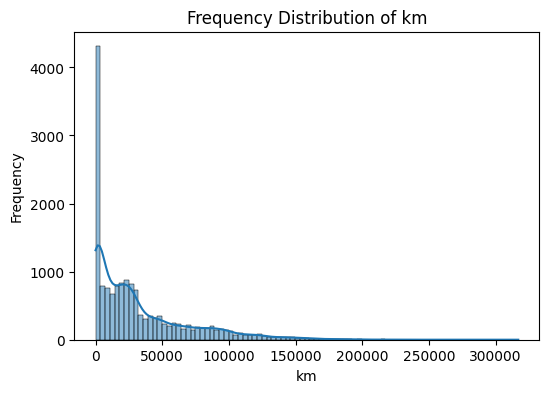

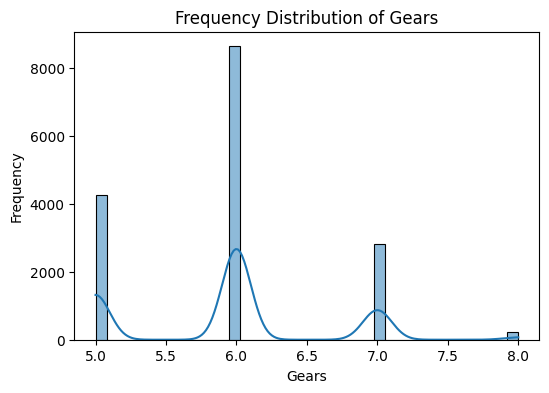

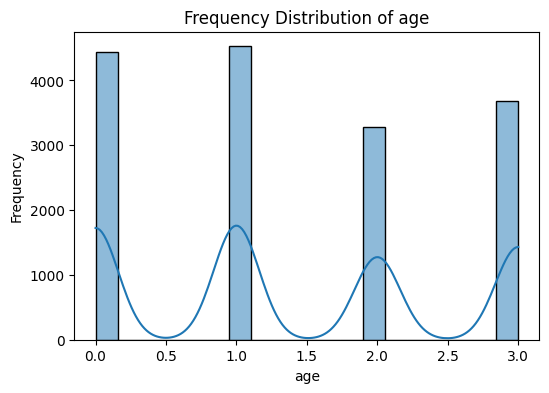

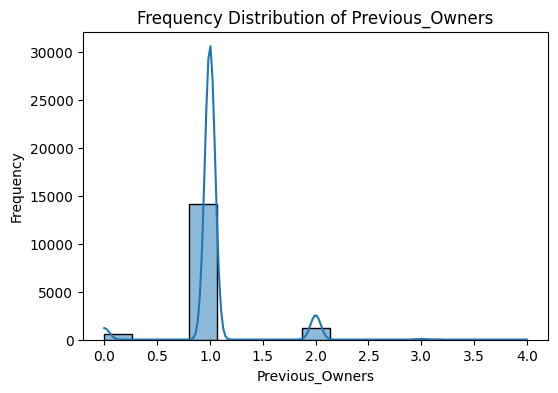

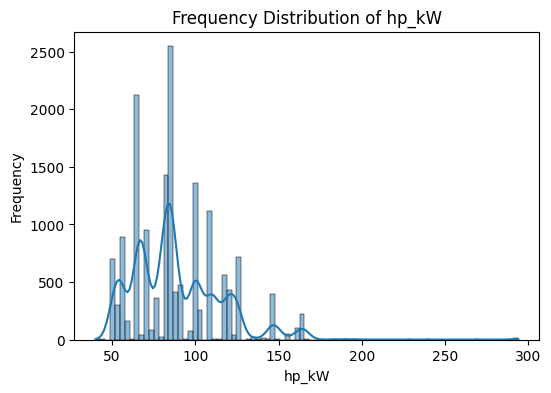

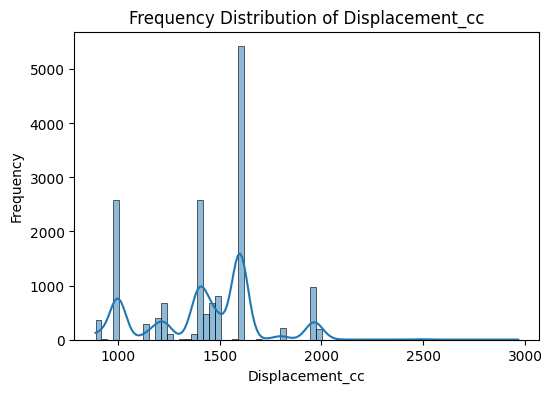

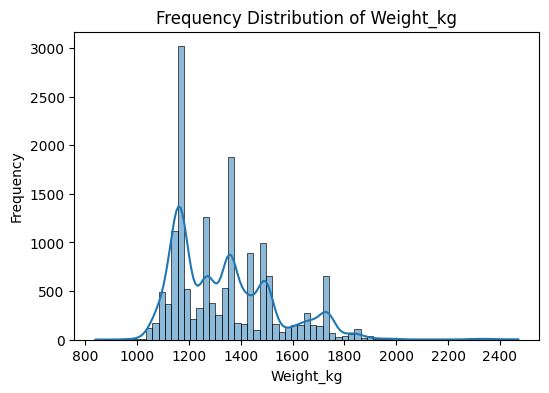

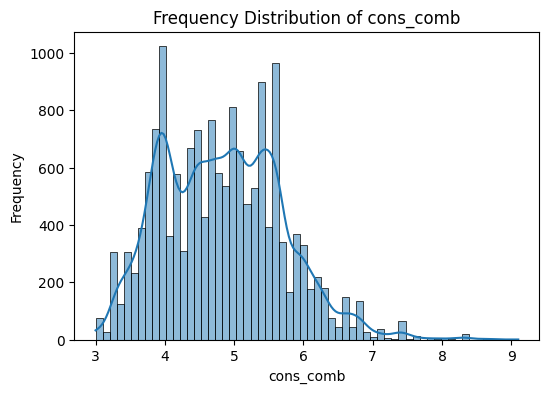

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
for col in numerical_features:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col],kde=True)
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.title(f'Frequency Distribution of {col}')

# Identify categorical columns and check their frequency distributions

Comfort_convenience,Entertainment, extra, safety security is being removed

In [ ]:
selected_category=['make_model','body_type','Type','Fuel']
selected_category=df[selected_category].columns
print('selected_category:')
print(selected_category)

selected_category:
Index(['make_model', 'body_type', 'Type', 'Fuel'], dtype='object')


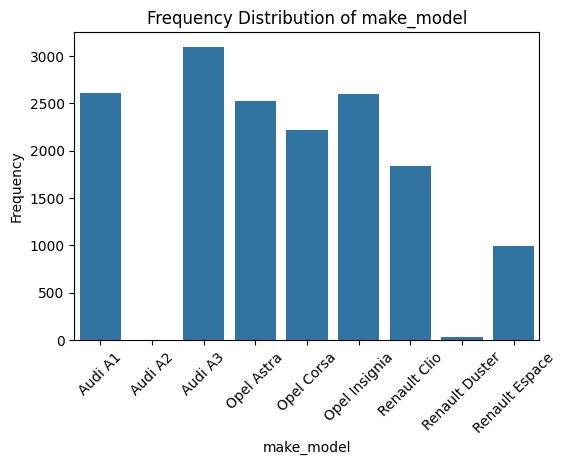

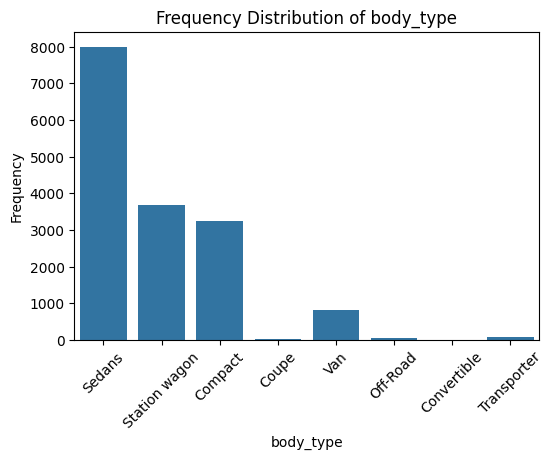

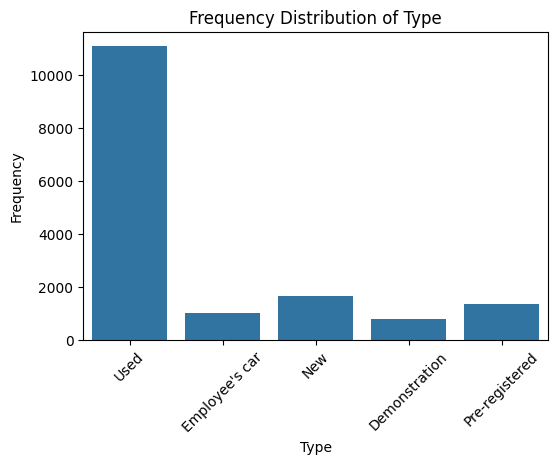

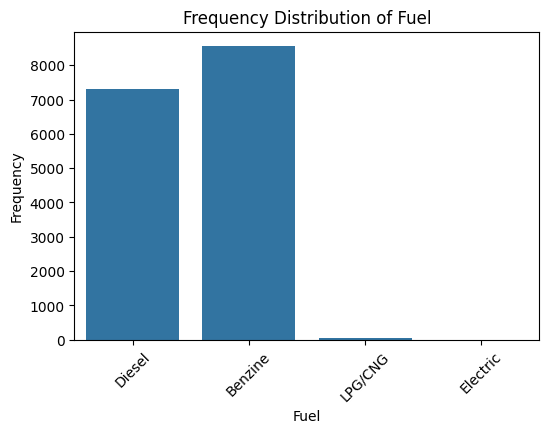

In [ ]:
for col in selected_category:
  plt.figure(figsize=(6,4))
  sns.countplot(data=df,x=col)
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.xticks(rotation=45)
  plt.title(f'Frequency Distribution of {col}')

Fix the column with the low frequency

Fix column as needed

In [ ]:
df['make_model']=df['make_model'].str.replace('Audi A2','',regex=False)
df['make_model']=df['make_model'].str.replace('Renault Duster','',regex=False)
df['make_model']=df['make_model'].str.replace('Ren','',regex=False)


In [ ]:
df.shape

(15915, 23)

Splitting the value of Comfort Convenience

In [ ]:
features_encoded = df['Comfort_Convenience'].str.get_dummies(sep=',')

In [ ]:
df = pd.concat([df, features_encoded], axis=1)


In [ ]:
df.shape

(15915, 61)

Splitting the values of entertainment media

In [ ]:
features_encoded_1 = df['Entertainment_Media'].str.get_dummies(sep=',')

In [ ]:
df = pd.concat([df, features_encoded_1], axis=1)

Splitting the values of Extras

In [ ]:
features_encoded_2 = df['Extras'].str.get_dummies(sep=',')

In [ ]:
df = pd.concat([df, features_encoded_2], axis=1)

Splitting values of Safety Security

In [ ]:
features_encoded_3 = df['Safety_Security'].str.get_dummies(sep=',')

In [ ]:
df = pd.concat([df, features_encoded_3], axis=1)

In [ ]:
df.shape

(15915, 117)

In [ ]:
df.to_csv('cleaned_data.csv',index=False)

In [ ]:
df.head(2)

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,0,0,1,1,0,1,1,1,0,1
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,0,0,1,1,0,1,1,1,0,1


In [ ]:
df_1=pd.read_csv('/content/cleaned_data.csv')

In [ ]:
df_1.shape

(15915, 117)

In [ ]:
df_1['make_model'].value_counts()

,count
make_model,
Audi A3,3097
Audi A1,2614
Opel Insignia,2598
Opel Astra,2525
Opel Corsa,2216
ault Clio,1839
ault Espace,991


In [ ]:
df_1['body_type']=df_1['body_type'].str.replace('Coupe','',regex=False)
df_1['body_type']=df_1['body_type'].str.replace('Off-Road','',regex=False)
df_1['body_type']=df_1['body_type'].str.replace('Convertible','',regex=False)
df_1['body_type']=df_1['body_type'].str.replace('Transporter','',regex=False)

In [ ]:
df_1['body_type'].value_counts()

,count
body_type,
Sedans,8004
Station wagon,3677
Compact,3240
Van,817
,177


In [ ]:
df_1['Fuel']=df_1['Fuel'].str.replace('LPG/CNG','',regex=False)
df_1['Fuel']=df_1['Fuel'].str.replace('Electric','',regex=False)

In [ ]:
df_1['Fuel'].value_counts()

,count
Fuel,
Benzine,8548
Diesel,7298
,69


Identify the target variable and plot the necessary distribution.Apply necessary transformation

# Plot histograms for target feature

Text(0.5, 1.0, 'Frequency Distribution of price')

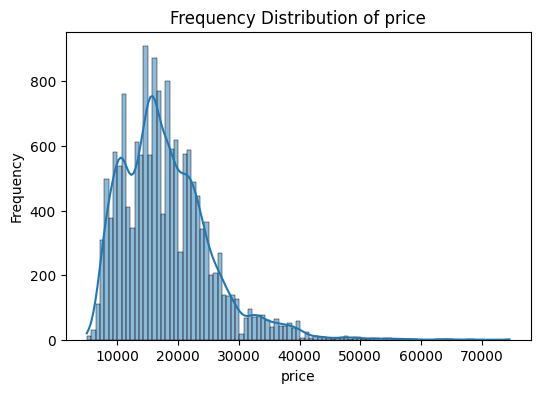

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.histplot(df['price'],kde=True)
plt.xlabel('price')
plt.ylabel('Frequency')
plt.title('Frequency Distribution of price')

# Transform the target feature

In [ ]:
df_1['price'].skew()

np.float64(-0.0314736417467197)

In [ ]:
df_1['price']=np.log1p(df_1['price'])

2.2 Correlation Analysis

Plot the Corrrelation map between the features and the target

In [ ]:
numerical_features=df_1.select_dtypes(include='float64').columns

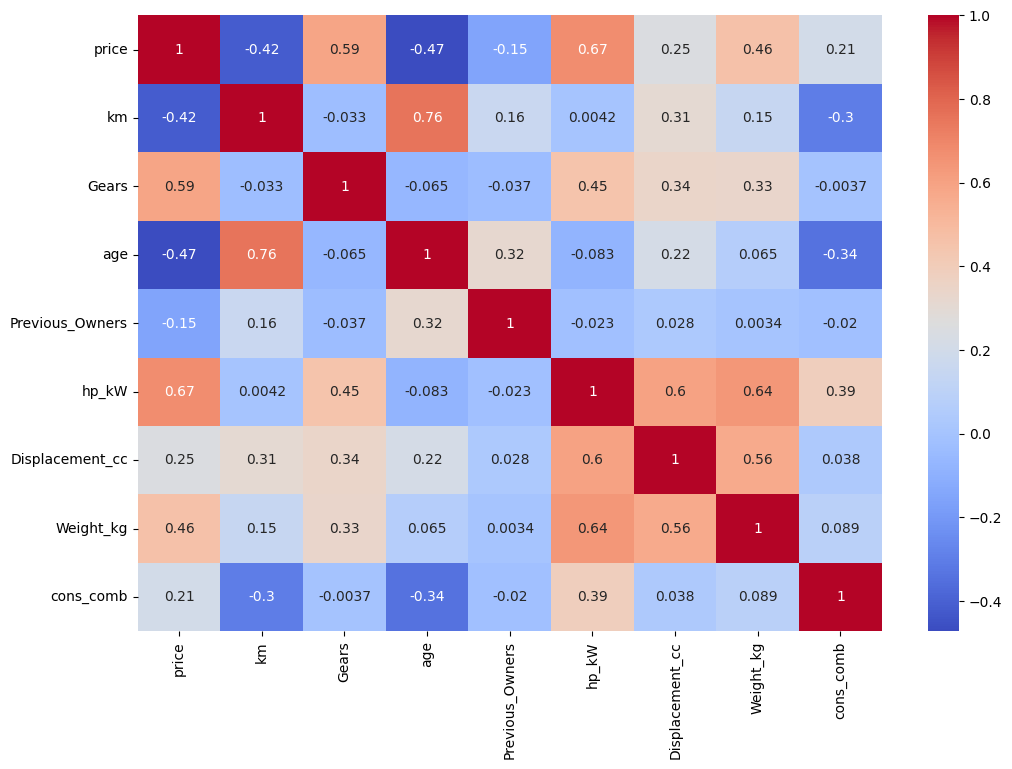

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df_1[numerical_features].corr(), annot=True, cmap='coolwarm')
plt.show()

# Visualise correlation

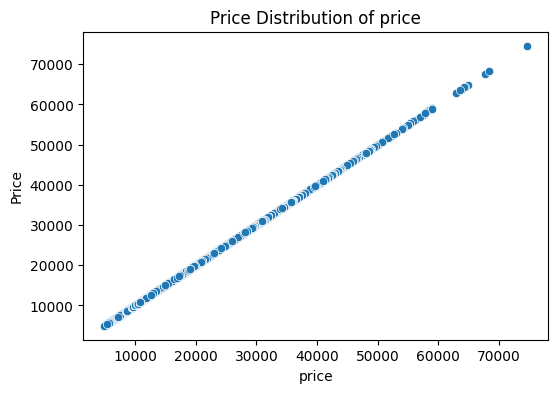

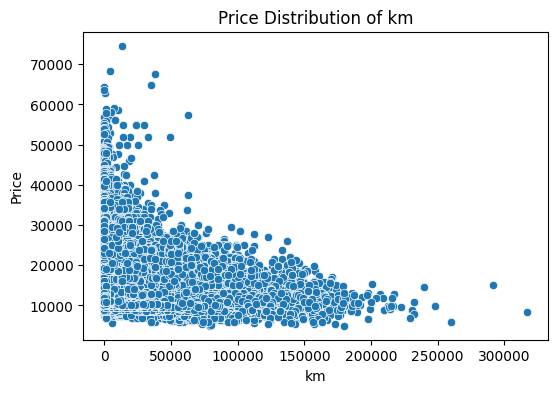

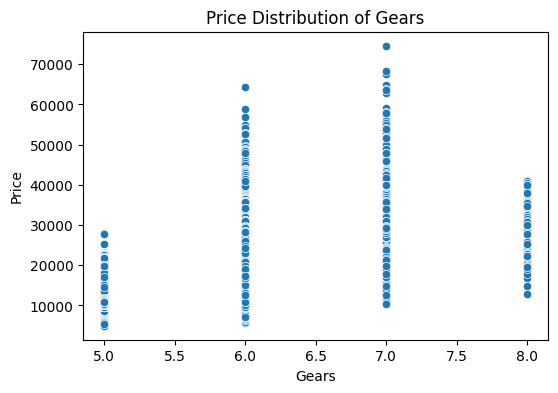

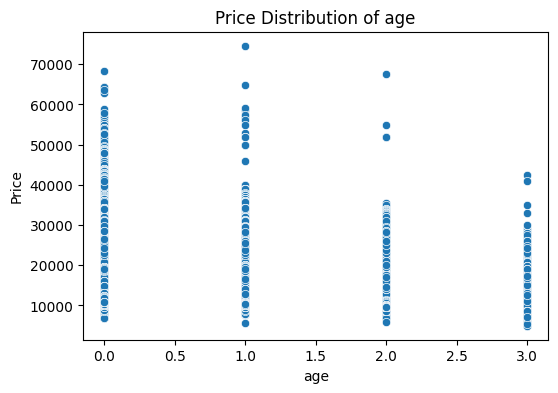

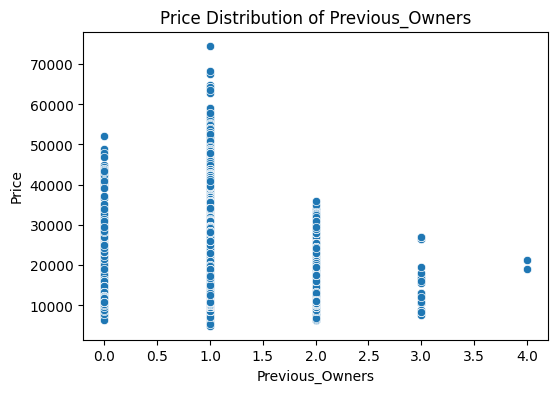

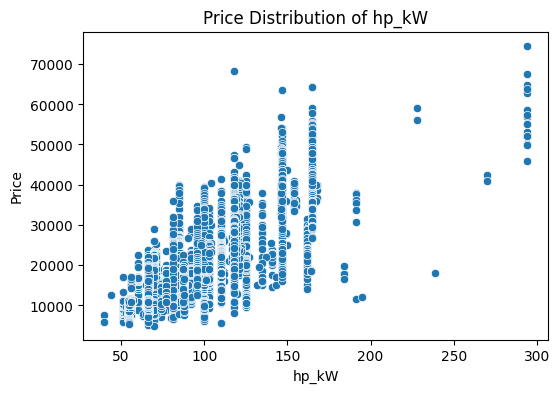

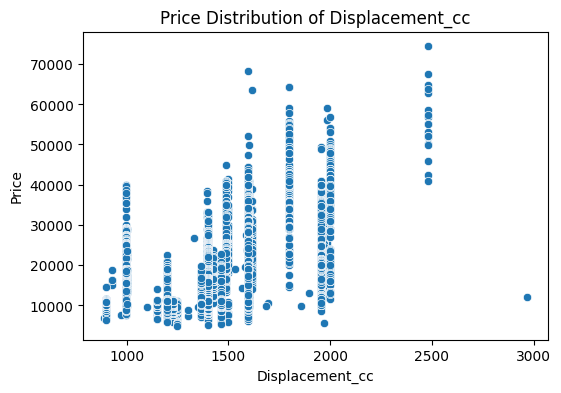

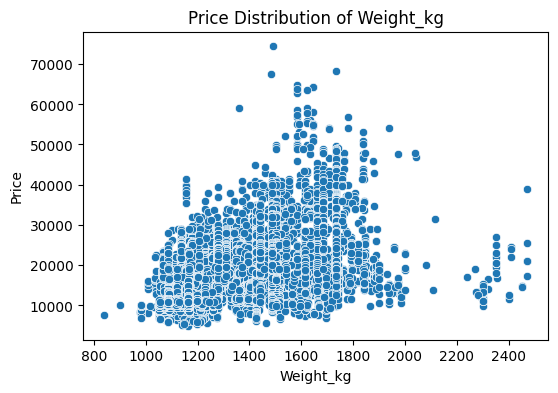

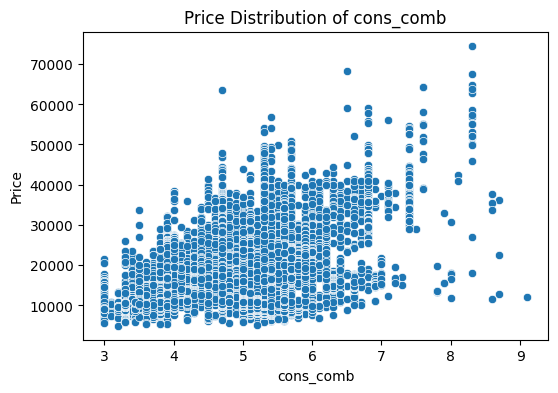

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
for col in numerical_features:
  plt.figure(figsize=(6,4))
  sns.scatterplot(data=df,x=df[col],y=df['price'])
  plt.xlabel(col)
  plt.ylabel('Price')
  plt.title(f'Price Distribution of {col}')


Analyze the correlation between categorical feature and target variable

# Comparing average values of target for different categories

In [ ]:
avg_price_type=df_1.groupby(['make_model','body_type','Type','Fuel'])['price'].mean().sort_values(ascending=False)
print(avg_price_type)

make_model   body_type      Type            Fuel   
ault Espace  Station wagon  New             Diesel     2.463639
             Sedans         New             Diesel     2.458636
             Station wagon  New             Benzine    2.456914
             Van            New             Benzine    2.456718
             Station wagon  Demonstration   Diesel     2.456564
                                                         ...   
Opel Corsa   Compact        Used            Diesel     2.298066
             Sedans         Used            Diesel     2.297973
                            Used            Diesel     2.288002
ault Clio    Sedans         Employee's car             2.287130
                            Pre-registered             2.287130
Name: price, Length: 214, dtype: float64


In [ ]:
df_1.shape

(15915, 117)

Outlier Analysis

# Outliers present in each column

In [ ]:
outlier=df_1.describe()
outlier

,price,km,Gears,age,Previous_Owners,hp_kW,Inspection_new,Displacement_cc,Weight_kg,cons_comb,...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights
count,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,...,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000
mean,2.371491,32089.995708,5.937355,1.389695,1.042853,88.499340,0.247063,1428.661891,1337.700534,4.832124,...,0.199686,0.004713,0.900597,0.910399,0.054665,0.879548,0.727427,0.744266,0.129312,0.232045
std,0.037225,36977.214964,0.704772,1.121306,0.339178,26.674341,0.431317,275.804272,199.682385,0.867530,...,0.399777,0.068488,0.299212,0.285618,0.227333,0.325500,0.445297,0.436286,0.335555,0.422151
min,2.252065,0.000000,5.000000,0.000000,0.000000,40.000000,0.000000,890.000000,840.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.347671,1920.500000,5.000000,0.000000,1.000000,66.000000,0.000000,1229.000000,1165.000000,4.100000,...,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,2.373521,20413.000000,6.000000,1.000000,1.000000,85.000000,0.000000,1461.000000,1295.000000,4.800000,...,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
75%,2.397376,46900.000000,6.000000,2.000000,1.000000,103.000000,0.000000,1598.000000,1472.000000,5.400000,...,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
max,2.503067,317000.000000,8.000000,3.000000,4.000000,294.000000,1.000000,2967.000000,2471.000000,9.100000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Handle Outlier

Handle Outlier

In [ ]:
df_1.shape

(15915, 117)

In [ ]:
##Removing of the outlier

In [ ]:
df_1 = df_1.drop(df_1['Gears'].idxmax())

In [ ]:
df_1=df_1.drop(df_1['hp_kW'].idxmax())

In [ ]:
df_1=df_1.drop(df_1['km'].idxmax())

In [ ]:
df_1=df_1.drop(df_1['Displacement_cc'].idxmax())

In [ ]:
df_1.shape

(15911, 117)

In [ ]:
df_1.to_csv('cleaned_data_2.csv',index=False)

In [ ]:
df_2=pd.read_csv('/content/cleaned_data_2.csv')

In [ ]:
df_2.shape

(15911, 117)

In [ ]:
##Remove the duplicate column

In [ ]:
df_2=df_2.loc[:,~df_2.columns.duplicated()]

In [ ]:
df_2.columns[df_2.columns.duplicated()]

Index([], dtype='object')

In [ ]:
constant_cols = [col for col in df_2.columns if df_2[col].nunique() == 1]

df_2.drop(columns=constant_cols, inplace=True)

print("Removed columns:", constant_cols)

Removed columns: []


In [ ]:
num_df = df_2.select_dtypes(include=['int64','float64'])

In [ ]:
corr_matrix = num_df.corr().abs()

In [ ]:
import numpy as np

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [col for col in upper.columns if any(upper[col] > 0.9)]

print(high_corr)

[]


In [ ]:
df = df.drop(columns=high_corr)

In [ ]:
df_2.shape

(15911, 117)

In [ ]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15911 entries, 0 to 15910
Columns: 117 entries, make_model to Xenon headlights
dtypes: float64(9), int64(95), object(13)
memory usage: 14.2+ MB


Drop the features from df

In [ ]:
feature_counts = df_2.select_dtypes(include='number').sum()

print(feature_counts)

price                              3.773276e+04
km                                 5.101686e+08
Gears                              9.446700e+04
age                                2.210900e+04
Previous_Owners                    1.659300e+04
                                       ...     
Side airbag                        1.399400e+04
Tire pressure monitoring system    1.157400e+04
Traction control                   1.184100e+04
Traffic sign recognition           2.057000e+03
Xenon headlights                   3.693000e+03
Length: 104, dtype: float64


In [ ]:
df_2 = df_2.replace({'Yes':1, 'No':0})

In [ ]:
df_2.shape

(15911, 117)

In [ ]:
df_2.to_csv('cleaned_data_3.csv',index=False)

In [ ]:
df_3=pd.read_csv('/content/cleaned_data_3.csv')

In [ ]:
df_3.nunique()

,0
make_model,7
body_type,4
price,2951
vat,2
km,6689
...,...
Side airbag,2
Tire pressure monitoring system,2
Traction control,2
Traffic sign recognition,2


Drop features from df

In [ ]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15911 entries, 0 to 15910
Columns: 117 entries, make_model to Xenon headlights
dtypes: float64(9), int64(95), object(13)
memory usage: 14.2+ MB


In [ ]:
cols_to_delete = [
'Air conditioning','Air suspension','Armrest','Automatic climate control','Auxiliary heating',
'Cruise control','Electric Starter','Electric tailgate','Electrical side mirrors',
'Electrically adjustable seats','Electrically heated windshield','Heads-up display',
'Heated steering wheel','Hill Holder','Keyless central door lock','Leather seats',
'Leather steering wheel','Light sensor','Lumbar support','Massage seats',
'Multi-function steering wheel','Navigation system','Panorama roof','Park Distance Control',
'Parking assist system camera','Parking assist system self-steering',
'Parking assist system sensors front','Parking assist system sensors rear',
'Power windows','Rain sensor','Seat heating','Seat ventilation','Split rear seats',
'Start-stop system','Sunroof','Tinted windows','Wind deflector','Windshield',
'Bluetooth','CD player','Digital radio','Hands-free equipment','MP3','On-board computer',
'Radio','Sound system','Television','USB','Alloy wheels','Cab or rented Car',
'Catalytic Converter','Handicapped enabled','Right hand drive','Roof rack',
'Shift paddles','Ski bag','Sliding door','Sport package','Sport seats','Sport suspension',
'Touch screen','Trailer hitch','Tuned car','Voice Control','Winter tyres','ABS',
'Adaptive Cruise Control','Adaptive headlights','Alarm system','Blind spot monitor',
'Central door lock','Central door lock with remote control','Daytime running lights',
'Driver drowsiness detection','Driver-side airbag','Electronic stability control',
'Emergency brake assistant','Emergency system','Fog lights','Head airbag','Immobilizer',
'Isofix','LED Daytime Running Lights','LED Headlights','Lane departure warning system',
'Night view assist','Passenger-side airbag','Power steering','Rear airbag','Side airbag',
'Tire pressure monitoring system','Traction control','Traffic sign recognition',
'Xenon headlights'
]

df_3 = df_3.drop(columns=cols_to_delete)

In [ ]:
df_3.shape

(15911, 23)

In [ ]:
df_3.to_csv('cleaned_data_4.csv',index=False)

# Encode features

In [ ]:
df_4=pd.read_csv('/content/cleaned_data_4.csv')

In [ ]:
cols_to_encode = ['make_model', 'Fuel', 'Type', 'body_type', 'Gearing_Type']

In [ ]:
df_4 = pd.get_dummies(df_4, columns=cols_to_encode, drop_first=True)

In [ ]:
print(df_4.head())

      price               vat       km  Gears  \
0  2.367054    VAT deductible  56013.0    7.0   
1  2.359152  Price negotiable  80000.0    7.0   
2  2.360059    VAT deductible  83450.0    7.0   
3  2.359152    VAT deductible  73000.0    6.0   
4  2.372913    VAT deductible  16200.0    7.0   

                                 Comfort_Convenience  \
0  Air conditioning,Armrest,Automatic climate con...   
1  Air conditioning,Automatic climate control,Hil...   
2  Air conditioning,Cruise control,Electrical sid...   
3  Air suspension,Armrest,Auxiliary heating,Elect...   
4  Air conditioning,Armrest,Automatic climate con...   

                                 Entertainment_Media  \
0  Bluetooth,Hands-free equipment,On-board comput...   
1  Bluetooth,Hands-free equipment,On-board comput...   
2                              MP3,On-board computer   
3  Bluetooth,CD player,Hands-free equipment,MP3,O...   
4  Bluetooth,CD player,Hands-free equipment,MP3,O...   

                               

In [ ]:
print(df_4.shape)

(15911, 34)


# Split data

In [ ]:
print(df_4.columns)

Index(['price', 'vat', 'km', 'Gears', 'Comfort_Convenience',
       'Entertainment_Media', 'Extras', 'Safety_Security', 'age',
       'Previous_Owners', 'hp_kW', 'Inspection_new', 'Paint_Type',
       'Upholstery_type', 'Displacement_cc', 'Weight_kg', 'Drive_chain',
       'cons_comb', 'make_model_Audi A3', 'make_model_Opel Astra',
       'make_model_Opel Corsa', 'make_model_Opel Insignia',
       'make_model_ault Clio', 'make_model_ault Espace', 'Fuel_Diesel',
       'Type_Employee's car', 'Type_New', 'Type_Pre-registered', 'Type_Used',
       'body_type_Sedans', 'body_type_Station wagon', 'body_type_Van',
       'Gearing_Type_Manual', 'Gearing_Type_Semi-automatic'],
      dtype='object')


In [ ]:
X = df_4.drop('price', axis=1)
y = df_4['price']

In [ ]:
X=df_4[['make_model_Audi A3', 'make_model_Opel Astra',
       'make_model_Opel Corsa', 'make_model_Opel Insignia',
       'make_model_ault Clio', 'make_model_ault Espace', 'Fuel_Diesel',
       'body_type_Sedans', 'body_type_Station wagon', 'body_type_Van',
       'Gearing_Type_Manual', 'Gearing_Type_Semi-automatic','km','Previous_Owners','age']]

In [ ]:
y=df_4['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,random_state=42)

# Scale features

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
import pandas as pd

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

Linear Regression model

3.1 Baseline Regression model

Build and fit the basic linear regression model. Perform using suitable matrix

# Initialise and train model

In [ ]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
##Make the Prediction
y_pred=model.predict(X_test)

In [ ]:
print("Intercept:",model.intercept_)
print("Coefficient:",model.coef_)

Intercept: 2.411254704116464
Coefficient: [ 1.45506459e-02 -1.37626238e-02 -5.15238807e-02  1.19881122e-02
 -4.03600371e-02  3.31542490e-02 -2.70641948e-03 -8.79419057e-04
  9.72423211e-04  3.80289022e-03 -2.14139247e-02  1.24450782e-02
 -1.99492307e-07  8.34210671e-04 -1.10066994e-02]


# Evaluate the model's performance

In [ ]:
mse=mean_squared_error(y_test,y_pred)
rmse=mse*0.5
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

Printing the result

In [ ]:
print("Mean Square Error:",mse)
print("Root Mean Square Error:",rmse)
print("Mean Absolute Error:",mae)
print("R2 Score:",r2)
#

Mean Square Error: 0.00016704318435853781
Root Mean Square Error: 8.352159217926891e-05
Mean Absolute Error: 0.009329081849775678
R2 Score: 0.8794839782314853


Analyse residual and check the other residual of linear regression

Check for linearity and prediction value

# Linearity check: Plot residuals vs fitted values

In [ ]:
residuals=y_test-y_pred

Text(0.5, 1.0, 'Linearity Check: Residuals vs Fitted Values')

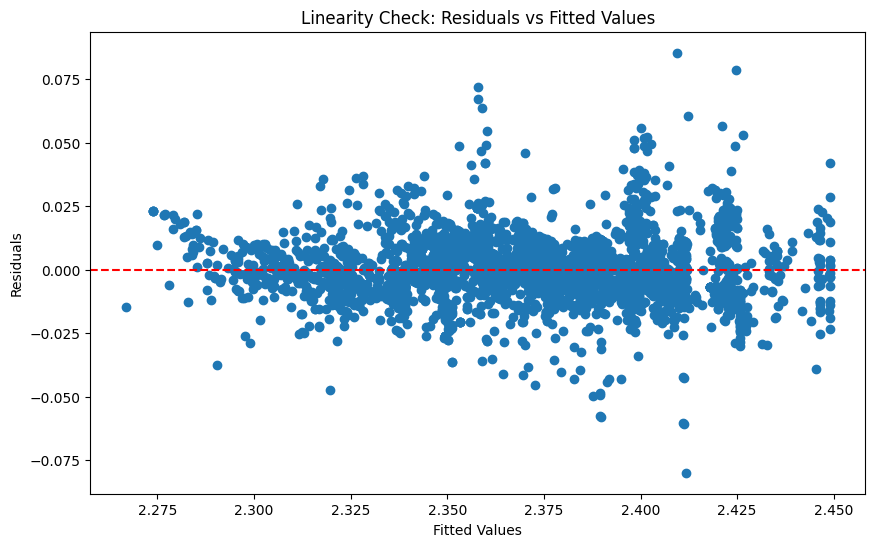

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(y_pred,residuals)
plt.axhline(y=0,color='r',linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Linearity Check: Residuals vs Fitted Values')

Check normality and residual distributio

# Check the normality of residuals by plotting their distribution

Text(0.5, 1.0, 'Distribution of Residuals')

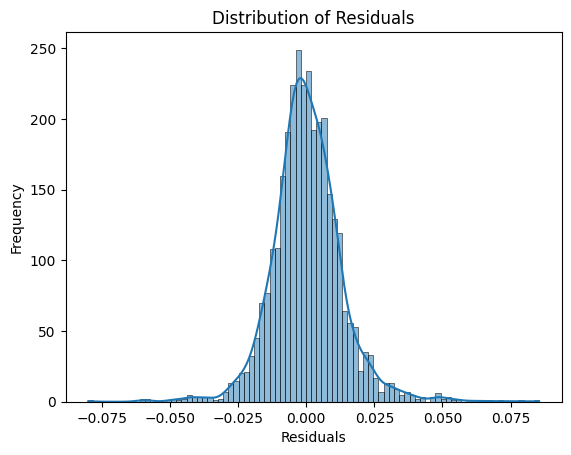

In [ ]:
sns.histplot(residuals,kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')

Check the multicolinearity using the variance Inflation Factor and handle the feature of higher VIF

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
print(X.dtypes)

make_model_Audi A3                bool
make_model_Opel Astra             bool
make_model_Opel Corsa             bool
make_model_Opel Insignia          bool
make_model_ault Clio              bool
make_model_ault Espace            bool
Fuel_Diesel                       bool
body_type_Sedans                  bool
body_type_Station wagon           bool
body_type_Van                     bool
Gearing_Type_Manual               bool
Gearing_Type_Semi-automatic       bool
km                             float64
Previous_Owners                float64
age                            float64
dtype: object


In [ ]:
X_numeric = X.select_dtypes(include=['int64','float64'])

In [ ]:
vif_data = pd.DataFrame()

In [ ]:
vif_data["Feature"] = X_numeric.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_numeric.values, i)
    for i in range(X_numeric.shape[1])
]

print(vif_data)

           Feature       VIF
0               km  4.196536
1  Previous_Owners  2.841193
2              age  6.613085


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

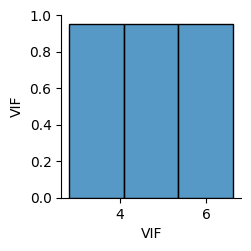

In [ ]:
sns.pairplot(vif_data)
plt.show()

Drop the Feature which has high VIF

In [ ]:
X_numeric = X_numeric.drop(columns=['age'])

In [ ]:
vif = pd.DataFrame()
vif["Feature"] = X_numeric.columns
vif["VIF"] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]

print(vif)

           Feature      VIF
0               km  1.77429
1  Previous_Owners  1.77429


Ridge Regression Implementation

Define a list of alpha values

# List of alphas to tune for Ridge regularisation

In [ ]:
##Generating the alphas
alphas=np.logspace(-3,2,num=50)

Apply ridge regularization and find the best value of the alpha from the list

In [ ]:
# Applying Ridge regression

In [ ]:
for alpha in alphas:
  ridge_model=Ridge(alpha=alpha)
  ridge_model.fit(X_train,y_train)
  score=ridge_model.score(X_test,y_test)
  print(f"Alpha:{alpha},Score:{score}")

Alpha:0.001,Score:0.8794839781511089
Alpha:0.0012648552168552957,Score:0.8794839781296273
Alpha:0.0015998587196060573,Score:0.8794839781023426
Alpha:0.0020235896477251575,Score:0.8794839780676499
Alpha:0.002559547922699536,Score:0.8794839780234784
Alpha:0.0032374575428176433,Score:0.8794839779671434
Alpha:0.004094915062380427,Score:0.8794839778951447
Alpha:0.005179474679231213,Score:0.8794839778028877
Alpha:0.006551285568595509,Score:0.879483977684294
Alpha:0.008286427728546842,Score:0.8794839775312475
Alpha:0.010481131341546858,Score:0.8794839773327985
Alpha:0.013257113655901095,Score:0.8794839770740024
Alpha:0.016768329368110083,Score:0.8794839767342073
Alpha:0.021209508879201904,Score:0.8794839762844906
Alpha:0.02682695795279726,Score:0.8794839756837936
Alpha:0.0339322177189533,Score:0.8794839748730219
Alpha:0.04291934260128778,Score:0.8794839737659816
Alpha:0.054286754393238594,Score:0.8794839722353476
Alpha:0.06866488450043001,Score:0.8794839700908124
Alpha:0.08685113737513529,Sco

Plot the best train and test score

In [ ]:
train_scores=[]
test_scores=[]
for alpha in alphas:
  ridge_model=Ridge(alpha=alpha)
  ridge_model.fit(X_train,y_train)
  train_scores.append(ridge_model.score(X_train,y_train))
  test_scores.append(ridge_model.score(X_test,y_test))

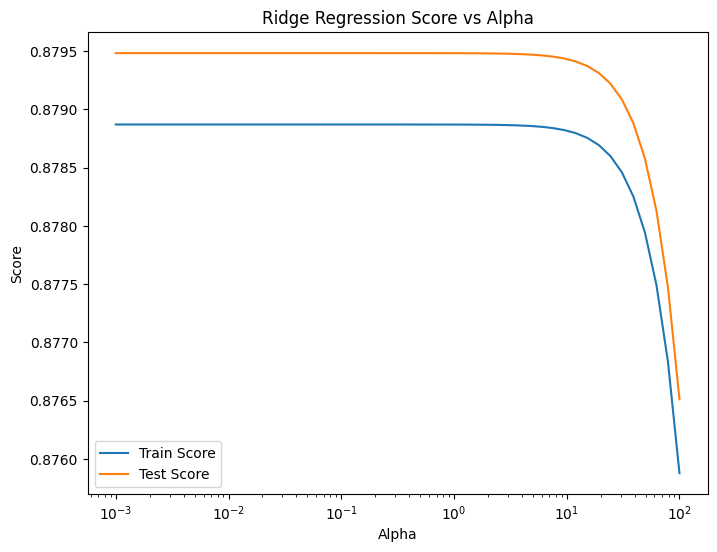

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(alphas,train_scores,label='Train Score')
plt.plot(alphas,test_scores,label='Test Score')
plt.xlabel('Alpha')
plt.ylabel('Score')
plt.xscale('log')
plt.title('Ridge Regression Score vs Alpha')
plt.legend()
plt.show()

Find the best alpha values

In [ ]:
# Best alpha value

In [ ]:
best_alpha=alphas[np.argmax(test_scores)]
print("Best Alpha:",best_alpha)

Best Alpha: 0.001


# Best score (negative MAE)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

ridge = Ridge()

param_grid = {"alpha":[0.001,0.01,0.1,1,10,100]}

grid = GridSearchCV(ridge, param_grid, scoring="neg_mean_absolute_error", cv=5)

grid.fit(X_train, y_train)

print("Best alpha:", grid.best_params_)
print("Best score (negative MAE):", grid.best_score_)

Best alpha: {'alpha': 0.001}
Best score (negative MAE): -0.009449007124955992


3.2.1 Fine tune by taking the closer range of alpha with the closer result

# Take a smaller range of alpha to test

In [ ]:
import numpy as np
small_alphas=np.linspace(0.5,1.5,7)

# Applying Ridge regression

In [ ]:
test_score=[]
train_score=[]
for alpha in small_alphas:
  ridge_model=Ridge(alpha=alpha)
  ridge_model.fit(X_train,y_train)
  test_score.append(ridge_model.score(X_test,y_test))
  train_score.append(ridge_model.score(X_train,y_train))

Plot the error-alpha graph again and find the actual optimal value of alpha

In [ ]:
# Plot train and test scores against alpha

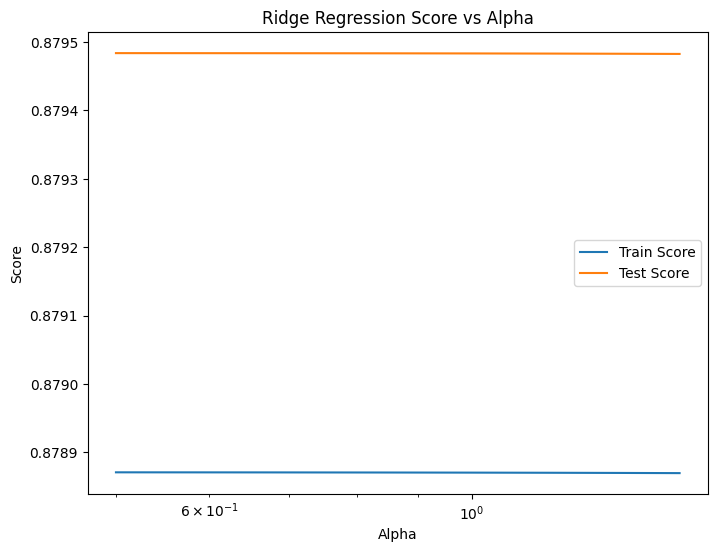

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(small_alphas,train_score,label='Train Score')
plt.plot(small_alphas,test_score,label='Test Score')
plt.xlabel('Alpha')
plt.ylabel('Score')
plt.xscale('log')
plt.title('Ridge Regression Score vs Alpha')
plt.legend()
plt.show()

# Best alpha value

In [ ]:
##Best alpha
best_alpha=small_alphas[np.argmax(test_score)]
print("Best Alpha:",best_alpha)

Best Alpha: 0.5


# Best score (negative MAE)


# Set best alpha for Ridge regression

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

ridge = Ridge()

param_grid = {"alpha":[0.5, 0.7, 0.9, 1, 1.1, 1.3, 1.5]}
grid= GridSearchCV(ridge, param_grid, scoring="neg_mean_absolute_error", cv=5)
grid.fit(X_train,y_train)

print("Best score (negative MAE):", grid.best_score_)
print("Best alpha:", grid.best_params_)

Best score (negative MAE): -0.009449433844212922
Best alpha: {'alpha': 0.5}


# Fit the Ridge model to get the coefficients of the fitted model

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

In [ ]:
ridge_model=Ridge(alpha=0.5)
ridge_model.fit(X_train,y_train)
print("Intercept:",ridge_model.intercept_)
print("Coefficient:",ridge_model.coef_)

Intercept: 2.411242557012153
Coefficient: [ 1.45558953e-02 -1.37506144e-02 -5.14955893e-02  1.19915624e-02
 -4.03364392e-02  3.30644588e-02 -2.69883284e-03 -8.76977599e-04
  9.76653249e-04  3.89797158e-03 -2.14153333e-02  1.24309780e-02
 -1.99544075e-07  8.32031139e-04 -1.10051669e-02]


# Show the coefficients for each feature

In [ ]:
coef_df=pd.DataFrame({"Features":X_train.columns,"Coefficient":ridge_model.coef_})
print(coef_df)

                       Features   Coefficient
0            make_model_Audi A3  1.455590e-02
1         make_model_Opel Astra -1.375061e-02
2         make_model_Opel Corsa -5.149559e-02
3      make_model_Opel Insignia  1.199156e-02
4          make_model_ault Clio -4.033644e-02
5        make_model_ault Espace  3.306446e-02
6                   Fuel_Diesel -2.698833e-03
7              body_type_Sedans -8.769776e-04
8       body_type_Station wagon  9.766532e-04
9                 body_type_Van  3.897972e-03
10          Gearing_Type_Manual -2.141533e-02
11  Gearing_Type_Semi-automatic  1.243098e-02
12                           km -1.995441e-07
13              Previous_Owners  8.320311e-04
14                          age -1.100517e-02


# Evaluate the Ridge model on the test data

In [ ]:
y_pred=ridge_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [ ]:
##Calculate the model performance
mse=mean_squared_error(y_test,y_pred)
rmse=mse*0.5
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [ ]:
print("Mean Square Error:",mse)
print("Root Mean Square Error:",rmse)
print("Mean Absolute Error:",mae)
print("R2 Score:",r2)

Mean Square Error: 0.00016704343397278899
Root Mean Square Error: 8.352171698639449e-05
Mean Absolute Error: 0.00932962930569822
R2 Score: 0.8794837981432246


Lasso Regression Implementation

In [ ]:
##Define a list of alpha values

In [ ]:
alpha=np.logspace(-3,2,num=50)

Apply Ridge regularization and find the best value of alpha from list

In [ ]:
# List of alphas to tune for Lasso regularisation
from sklearn.linear_model import Lasso
alpha=np.logspace(-3,2,num=50)
# Initialise Lasso regression model
for alpha in alpha:
  lasso=Lasso(alpha=alpha)
  lasso.fit(X_train,y_train)

Apply Ridge Regularization and fid the best value of the alpha

In [ ]:
# Plot train and test scores against alpha

In [ ]:
alpha = [0.001, 0.01, 0.1, 1, 10]

train_score=[]
test_score=[]

for alp in alpha:

    lasso_model=Lasso(alpha=alp)

    lasso_model.fit(X_train,y_train)

    train_score.append(lasso_model.score(X_train,y_train))
    test_score.append(lasso_model.score(X_test,y_test))

# Best alpha value

In [ ]:
best_alpha=alpha[np.argmax(test_score)]
print("Best Alpha:",best_alpha)

Best Alpha: 0.001


# Best score (negative MAE)

In [ ]:
param_grid = {"alpha":[0.001, 0.01, 0.1, 1, 10]}

grid= GridSearchCV(lasso, param_grid, scoring="neg_mean_absolute_error", cv=5)

grid.fit(X_train,y_train)

print("Best score (negative MAE):", grid.best_score_)

Best score (negative MAE): -0.01129576039909248


Fine tune by taking the closer value of the alpha on the previous result

In [ ]:
# List of alphas to tune for Lasso regularization

In [ ]:
alphas=np.logspace(-2,2,num=50)

# Tuning Lasso hyperparameters

In [ ]:
lasso_final=Lasso(alpha=0.01)
lasso_final.fit(X_train,y_train)

Lasso(alpha=0.01)

In [ ]:
print(len(alphas))
print(len(train_score))
print(len(test_score))

50
5
5


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
train_score = []
test_score = []

for a in alphas:
    model = Lasso(alpha=a)
    model.fit(X_train_scaled, y_train)

    train_score.append(model.score(X_train_scaled, y_train))
    test_score.append(model.score(X_test_scaled, y_test))

In [ ]:
train_score = []
test_score = []

for a in alphas:
    model = Lasso(alpha=a)
    model.fit(X_train_scaled, y_train)

    train_score.append(model.score(X_train_scaled, y_train))
    test_score.append(model.score(X_test_scaled, y_test))

# Plot train and test scores against alpha

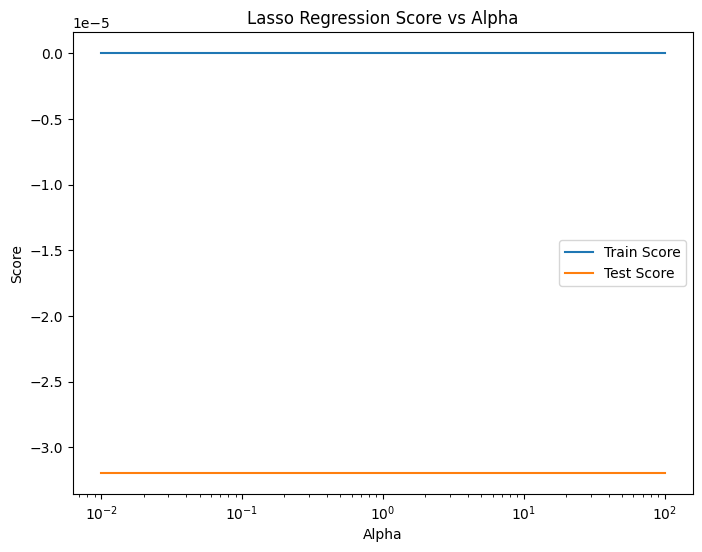

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(alphas,train_score,label='Train Score')
plt.plot(alphas,test_score,label='Test Score')
plt.xlabel('Alpha')
plt.ylabel('Score')
plt.xscale('log')
plt.title('Lasso Regression Score vs Alpha')
plt.legend()
plt.show()

# Best alpha value

In [ ]:
best_alpha=alphas[np.argmax(test_score)]
print("Best Alpha:",best_alpha)

Best Alpha: 0.01


# Best score (negative MAE)

In [ ]:
param_grid = {"alpha":[0.001, 0.01, 0.1, 1,]}
grid= GridSearchCV(lasso, param_grid, scoring="neg_mean_absolute_error", cv=5)
grid.fit(X_train,y_train)

print("Best score (negative MAE):", grid.best_score_)

Best score (negative MAE): -0.01129576039909248


# Set best alpha for Lasso regression

In [ ]:
best_alpha=alphas[np.argmax(test_score)]
print("Best Alpha:",best_alpha)

Best Alpha: 0.01


# Fit the Lasso model on scaled training data

In [ ]:
lasso_model=Lasso(alpha=0.01)
lasso_model.fit(X_train,y_train)

Lasso(alpha=0.01)

# Get the coefficients of the fitted model

In [ ]:
print("Intercept:",lasso_model.intercept_)
print("Coefficient:",lasso_model.coef_)

Intercept: 2.385003660365602
Coefficient: [ 0.00000000e+00 -0.00000000e+00 -0.00000000e+00  0.00000000e+00
 -0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
  0.00000000e+00  0.00000000e+00 -0.00000000e+00  0.00000000e+00
 -4.18460457e-07 -0.00000000e+00 -0.00000000e+00]


# Get the coefficients of the fitted model

In [ ]:
import pandas as pd
coef_df=pd.DataFrame({"Features":X_train.columns,"Coefficient":lasso_model.coef_})
print(coef_df)

                       Features   Coefficient
0            make_model_Audi A3  0.000000e+00
1         make_model_Opel Astra -0.000000e+00
2         make_model_Opel Corsa -0.000000e+00
3      make_model_Opel Insignia  0.000000e+00
4          make_model_ault Clio -0.000000e+00
5        make_model_ault Espace  0.000000e+00
6                   Fuel_Diesel  0.000000e+00
7              body_type_Sedans -0.000000e+00
8       body_type_Station wagon  0.000000e+00
9                 body_type_Van  0.000000e+00
10          Gearing_Type_Manual -0.000000e+00
11  Gearing_Type_Semi-automatic  0.000000e+00
12                           km -4.184605e-07
13              Previous_Owners -0.000000e+00
14                          age -0.000000e+00


# Evaluate the Lasso model on the test data

In [ ]:
y_pred=lasso_model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
rmse=mse*0.5
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [ ]:
print("Mean Square Error:",mse)
print("Root Mean Square Error:",rmse)
print("Mean Absolute Error:",mae)
print("R2 Score:",r2)

Mean Square Error: 0.0011373116885112693
Root Mean Square Error: 0.0005686558442556346
Mean Absolute Error: 0.02707161402773448
R2 Score: 0.17946798765510452


Regularisation Comparison and matrix

In [ ]:
##Compare the evaluation matrix of each model

In [ ]:
# Compare metrics for each model

In [ ]:
lr_model=LinearRegression()
lasso_model=Lasso(alpha=1)
ridge_model=Ridge(alpha=1)

In [ ]:
lr_model.fit(X_train,y_train)
lasso_model.fit(X_train,y_train)
ridge_model.fit(X_train,y_train)

Ridge(alpha=1)

In [ ]:
##Prediction

In [ ]:
lr_pred=lr_model.predict(X_test_scaled)
lasso_pred=lasso_model.predict(X_test_scaled)
ridge_pred=ridge_model.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


In [ ]:
results = {
    "Model": ["Linear Regression", "Lasso (L1)", "Ridge (L2)"],

    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, ridge_pred)
    ],

    "MSE": [
        mean_squared_error(y_test, lr_pred),
        mean_squared_error(y_test, lasso_pred),
        mean_squared_error(y_test, ridge_pred)
    ]
}

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)
print(results_df)

               Model  R2 Score       MSE
0  Linear Regression  0.569662  0.000596
1         Lasso (L1) -0.134618  0.001573
2         Ridge (L2)  0.569527  0.000597


Compare the coeffiecient of three models

Also visualize a few of the largest coefficient and coefficient droped by lasso

In [ ]:
# Compare highest coefficients and coefficients of eliminated features

In [ ]:
features_name=X.columns

In [ ]:
lr=LinearRegression()
lasso=Lasso(alpha=1)
ridge=Ridge(alpha=1)

In [ ]:
ridge.fit(X_train_scaled,y_train)
lasso.fit(X_train_scaled,y_train)
lr.fit(X_train_scaled,y_train)

LinearRegression()

In [ ]:
lr=LinearRegression()

In [ ]:
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
lasso_coef=lasso.coef_
ridge_coef=ridge.coef_
lr_coef=lr.coef_

In [ ]:
import pandas as pd
coef_df=pd.DataFrame({"Features":features_name,"Linear Regression":lr_coef,"Lasso":lasso_coef,"Ridge":ridge_coef})
print(coef_df)

                       Features  Linear Regression  Lasso     Ridge
0            make_model_Audi A3           0.014551    0.0  0.014542
1         make_model_Opel Astra          -0.013763   -0.0 -0.013758
2         make_model_Opel Corsa          -0.051524   -0.0 -0.051484
3      make_model_Opel Insignia           0.011988    0.0  0.011981
4          make_model_ault Clio          -0.040360   -0.0 -0.040319
5        make_model_ault Espace           0.033154    0.0  0.032966
6                   Fuel_Diesel          -0.002706    0.0 -0.002723
7              body_type_Sedans          -0.000879   -0.0 -0.000872
8       body_type_Station wagon           0.000972    0.0  0.000967
9                 body_type_Van           0.003803    0.0  0.003993
10          Gearing_Type_Manual          -0.021414   -0.0 -0.021426
11  Gearing_Type_Semi-automatic           0.012445    0.0  0.012422
12                           km          -0.058212   -0.0 -0.057592
13              Previous_Owners           0.0033

Highest coefficient

In [ ]:
top_features = coef_df.reindex(
    coef_df['Lasso'].abs().sort_values(ascending=False).index
)

In [ ]:
print(top_features.head(10))

                   Features  Linear Regression  Lasso     Ridge
0        make_model_Audi A3           0.014551    0.0  0.014542
1     make_model_Opel Astra          -0.013763   -0.0 -0.013758
2     make_model_Opel Corsa          -0.051524   -0.0 -0.051484
3  make_model_Opel Insignia           0.011988    0.0  0.011981
4      make_model_ault Clio          -0.040360   -0.0 -0.040319
5    make_model_ault Espace           0.033154    0.0  0.032966
6               Fuel_Diesel          -0.002706    0.0 -0.002723
7          body_type_Sedans          -0.000879   -0.0 -0.000872
8   body_type_Station wagon           0.000972    0.0  0.000967
9             body_type_Van           0.003803    0.0  0.003993


In [ ]:
eliminated_features = coef_df[coef_df['Lasso'] == 0]
print(eliminated_features)

                       Features  Linear Regression  Lasso     Ridge
0            make_model_Audi A3           0.014551    0.0  0.014542
1         make_model_Opel Astra          -0.013763   -0.0 -0.013758
2         make_model_Opel Corsa          -0.051524   -0.0 -0.051484
3      make_model_Opel Insignia           0.011988    0.0  0.011981
4          make_model_ault Clio          -0.040360   -0.0 -0.040319
5        make_model_ault Espace           0.033154    0.0  0.032966
6                   Fuel_Diesel          -0.002706    0.0 -0.002723
7              body_type_Sedans          -0.000879   -0.0 -0.000872
8       body_type_Station wagon           0.000972    0.0  0.000967
9                 body_type_Van           0.003803    0.0  0.003993
10          Gearing_Type_Manual          -0.021414   -0.0 -0.021426
11  Gearing_Type_Semi-automatic           0.012445    0.0  0.012422
12                           km          -0.058212   -0.0 -0.057592
13              Previous_Owners           0.0033